# Project Part 1

UPI: mkim670

Traffic Sign Recognition: MLP vs SVM

In [1]:
# --- Environment setup: install required packages in Colab ---
!pip -q install kagglehub pillow

# standard imports
import os, glob
import numpy as np
from PIL import Image
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import layers, models

import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (32, 32)  # target size for preprocessing

In [2]:
# --- Downloading Dataset ---
data_root = kagglehub.dataset_download("flo2607/traffic-signs-classification")
print("Downloaded to:", data_root)

# Find the directory that contains one subfolder per class
candidate = os.path.join(data_root, "myData")
if os.path.isdir(candidate):
    CLASS_ROOT = candidate
else:
    subdirs = [d for d in glob.glob(os.path.join(data_root, "*")) if os.path.isdir(d)]
    CLASS_ROOT = next(
        (d for d in subdirs if len([x for x in glob.glob(os.path.join(d, "*")) if os.path.isdir(x)]) >= 2),
        data_root
    )
print("Class root:", CLASS_ROOT)

# Return (paths, labels, class_names) from subfolders.
def load_paths_and_labels(root_dir):
    class_dirs = sorted([d for d in glob.glob(os.path.join(root_dir, "*")) if os.path.isdir(d)])
    class_names = [os.path.basename(d) for d in class_dirs]
    paths, labels = [], []
    for y, cdir in enumerate(class_dirs):
        for p in glob.glob(os.path.join(cdir, "*")):
            if p.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                paths.append(p); labels.append(y)
    return paths, np.array(labels, dtype=np.int32), class_names

# Load images, enforce RGB, resize to IMG_SIZE, and scale to [0,1]
def load_images(paths, size=IMG_SIZE):
    X = []
    for p in paths:
        img = Image.open(p).convert("RGB").resize(size)
        X.append(np.asarray(img, dtype=np.uint8))
    # normalise to [0,1]
    return (np.stack(X, axis=0).astype(np.float32) / 255.0)

# load file paths and labels, then actual image tensors
paths, y_all, class_names = load_paths_and_labels(CLASS_ROOT)
X_all = load_images(paths, size=IMG_SIZE)
print(f"Loaded {len(paths)} images across {len(class_names)} classes → X shape {X_all.shape}")


Using Colab cache for faster access to the 'traffic-signs-classification' dataset.
Downloaded to: /kaggle/input/traffic-signs-classification
Class root: /kaggle/input/traffic-signs-classification/myData
Loaded 73139 images across 43 classes → X shape (73139, 32, 32, 3)


In [3]:
# --- Train/Test Split & Transformations ---

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
print("Train:", X_train.shape, "Test:", X_test.shape)

# Flatten for SVM
X_train_f = X_train.reshape(len(X_train), -1)
X_test_f  = X_test.reshape(len(X_test), -1)

# Standardise features
scaler = StandardScaler(with_mean=True)
X_train_f = scaler.fit_transform(X_train_f)
X_test_f  = scaler.transform(X_test_f)

# PCA for dimensionality reduction
pca = PCA(n_components=100, whiten=True, random_state=SEED)
X_train_p = pca.fit_transform(X_train_f)
X_test_p  = pca.transform(X_test_f)
print("PCA shapes:", X_train_p.shape, X_test_p.shape)

Train: (58511, 32, 32, 3) Test: (14628, 32, 32, 3)
PCA shapes: (58511, 100) (14628, 100)


In [5]:
# --- MLP Model ---

mlp = models.Sequential([
    layers.Flatten(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(len(class_names), activation='softmax')
])

mlp.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mlp = mlp.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    verbose=1
)

# evaluate MLP on test set
mlp_test_pred = mlp.predict(X_test, verbose=0).argmax(axis=1)
mlp_test_acc  = accuracy_score(y_test, mlp_test_pred)
print(f"Test accuracy = {mlp_test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 69s 72ms/step - accuracy: 0.2194 - loss: 3.2146
Epoch 2/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 66s 72ms/step - accuracy: 0.5125 - loss: 1.6230
Epoch 3/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 65s 71ms/step - accuracy: 0.6087 - loss: 1.2929
Epoch 4/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 66s 72ms/step - accuracy: 0.6410 - loss: 1.1672
Epoch 5/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 65s 72ms/step - accuracy: 0.6779 - loss: 1.0603
Epoch 6/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 64s 70ms/step - accuracy: 0.7012 - loss: 0.9788
Epoch 7/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 64s 70ms/step - accuracy: 0.7207 - loss: 0.9181
Epoch 8/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 64s 70ms/step - accuracy: 0.7341 - loss: 0.8745
Epoch 9/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.7417 - loss: 0.8469
Epoch 10/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.7494 - loss: 0.8240
Epoch 11/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 84s 72ms/step - accuracy: 0.7613 - loss: 0.7860
Epoch 12/30
915/915 ━━━━━━━━━━

In [4]:
# --- SVM with PCA ---
svm = SVC(kernel="rbf", C=10, gamma="scale", cache_size=1000)
svm.fit(X_train_p, y_train)

svm_test_pred = svm.predict(X_test_p)
svm_test_acc  = accuracy_score(y_test, svm_test_pred)
print(f"[SVM] Test accuracy = {svm_test_acc:.4f}")


[SVM] Test accuracy = 0.9800


=== Summary ===
       Accuracy  Precision    Recall        F1
Model                                         
SVM    0.980038   0.986339  0.978177  0.982072
MLP    0.893150   0.909667  0.890335  0.894698


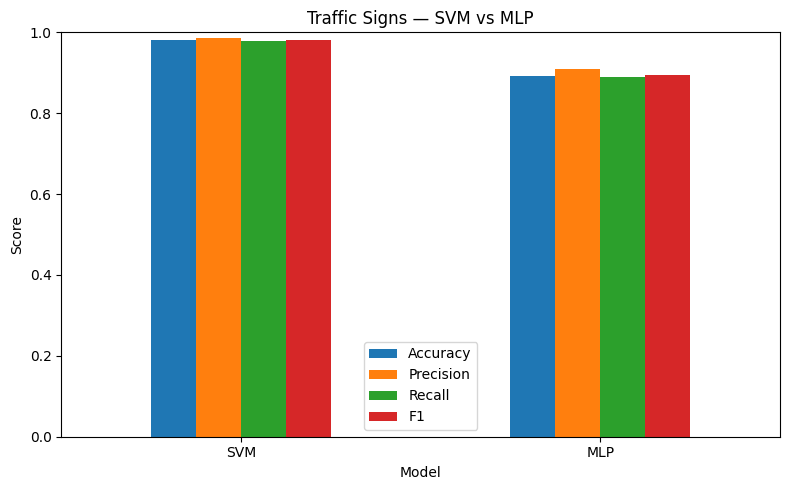

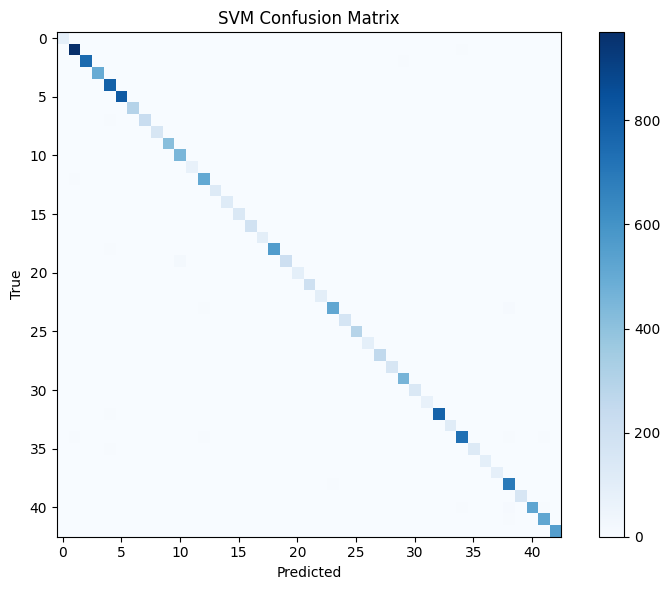

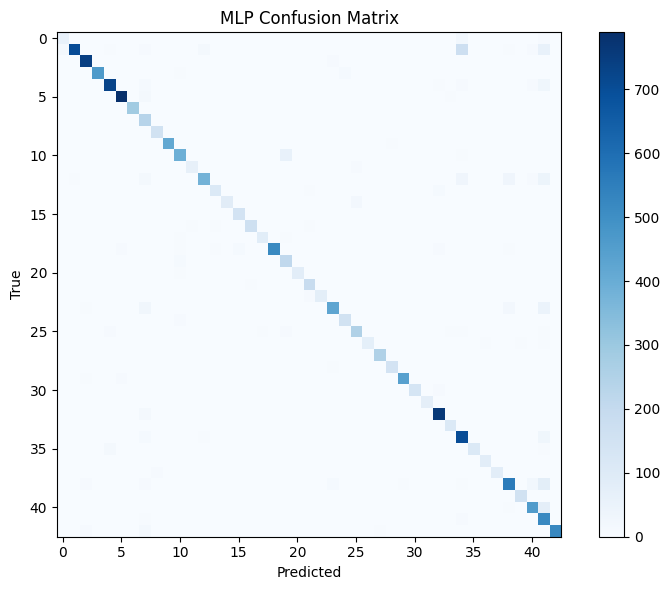

In [6]:
# --- Comparison ---

# compute metrics
summary = pd.DataFrame(
    [
        {
            "Model": "SVM",
            "Accuracy":  accuracy_score(y_test, svm_test_pred),
            "Precision": precision_score(y_test, svm_test_pred, average="macro"),
            "Recall":    recall_score(y_test, svm_test_pred, average="macro"),
            "F1":        f1_score(y_test, svm_test_pred, average="macro"),
        },
        {
            "Model": "MLP",
            "Accuracy":  accuracy_score(y_test, mlp_test_pred),
            "Precision": precision_score(y_test, mlp_test_pred, average="macro"),
            "Recall":    recall_score(y_test, mlp_test_pred, average="macro"),
            "F1":        f1_score(y_test, mlp_test_pred, average="macro"),
        },
    ]
).set_index("Model")

print("=== Summary ===")
print(summary)

# Bar chart
ax = summary.plot(kind="bar", figsize=(8,5))
ax.set_ylabel("Score")
ax.set_title("Traffic Signs — SVM vs MLP")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# function to plot confusion matrices
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# plot confusion matrices
plot_confusion_matrix(confusion_matrix(y_test, svm_test_pred), "SVM Confusion Matrix")
plot_confusion_matrix(confusion_matrix(y_test, mlp_test_pred),  "MLP Confusion Matrix")

